In [1]:
from matplotlib import pyplot as plt
import numpy as np
from astropy.io import fits
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import h5py
from scipy.ndimage import map_coordinates

In [2]:
import matplotlib.colors as mcolors
original_cmap = plt.get_cmap('Set1')

colors = original_cmap(np.arange(1,6,1))
Set11 = mcolors.ListedColormap(colors)

In [3]:
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.hpx.fits' 
eightsigmapeaksdat = fits.getdata(fn)
eightsigmapeakdshdr = fits.getheader(fn)
fn1 = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.car.fits' 
eightsigmapeakscardat = fits.getdata(fn1)
eightsigmapeakscarhdr = fits.getheader(fn1)

(70.0, 90.0)

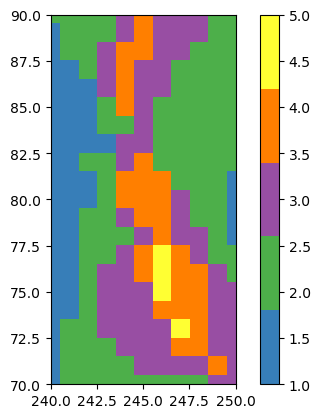

In [4]:
fig, ax = plt.subplots(1,1) 
im = ax.imshow(eightsigmapeakscardat, 
               cmap = Set11, vmin =1, vmax = 5,
               origin = 'lower'
              )
plt.colorbar(im)
ax.set_xlim(240,250)
ax.set_ylim(70,90)

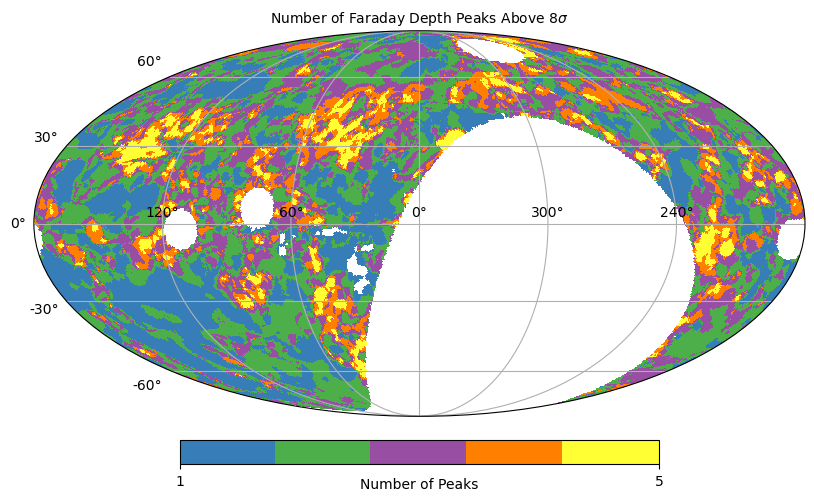

In [5]:
projview(
    eightsigmapeaksdat,
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    # xlabel="Longitude", 
    # ylabel="Latitude", 
    cb_orientation = "horizontal",
    cmap = Set11,
    min = 1, 
    max = 5,
    unit = r'Number of Peaks',
    title = r'Number of Faraday Depth Peaks Above 8$\sigma$', 
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

In [6]:
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.car.fits'
Npeakscardat = fits.getdata(fn)
Npeakscarhdr = fits.getheader(fn)

In [7]:
#loading dirty Faraday Depth Cube for spectra
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_tot_dirty_Kgal.car.fits'
FDdirtydat = fits.getdata(fn)
FDdirtyhdr = fits.getheader(fn)

In [8]:
#loading clean Faraday Depth Cube for spectra from DRAGONS
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_clean_tot_Kgal.car.fits'
FDcleandat = fits.getdata(fn) 
FDcleanhdr = fits.getheader(fn)

In [9]:
wcs = WCS(FDcleanhdr)
wcs

WCS Keywords

Number of WCS axes: 3
CTYPE : 'GLON-CAR' 'GLAT-CAR' 'FDEP'
CUNIT : 'deg' 'deg' 'rad / m2'
CRVAL : 0.0 0.0 0.0
CRPIX : 360.5 180.5 401.0
PC1_1 PC1_2 PC1_3  : 1.0 0.0 0.0
PC2_1 PC2_2 PC2_3  : 0.0 1.0 0.0
PC3_1 PC3_2 PC3_3  : 0.0 0.0 1.0
CDELT : -0.5 0.5 0.5
NAXIS : 720  360  801

In [10]:
FDcleanhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  720                                                  
NAXIS2  =                  360                                                  
NAXIS3  =                  801                                                  
COORDSYS= 'Galactic '          / Ecliptic, Galactic or Celestial (equatorial)   
CRPIX2  =                180.5                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'deg     '                                                            
BUNIT   = 'K/RMSF  '                                                            
CTYPE2  = 'GLAT-CAR'                                                            
CRVAL2  =                   

In [11]:
Npeakscarhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  720                                                  
NAXIS2  =                  360                                                  
COORDSYS= 'galactic'           / Ecliptic, Galactic or Celestial (equatorial)   
CRPIX2  =                180.5                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'deg     '                                                            
BUNIT   = 'NUMBER  '                                                            
CTYPE2  = 'GLAT-CAR'                                                            
CRVAL2  =                    0                                                  
CTYPE1  = 'GLON-CAR'        

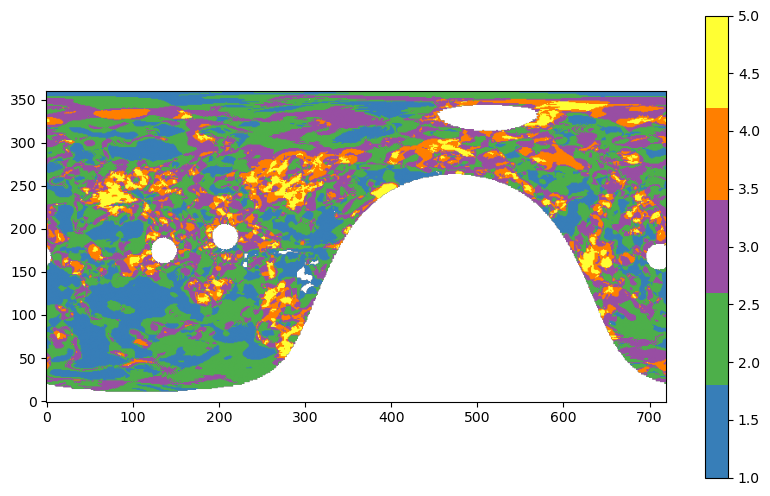

In [12]:
figsize = (10, 6)
fig, ax = plt.subplots(1,1, figsize = figsize)#, subplot_kw={'projection'})#: wcs.celestial})
im0 = ax.imshow(Npeakscardat, origin='lower', cmap = Set11, vmin=1, vmax=5)

plt.colorbar(im0)
plt.show()

In [13]:
mask = (Npeakscardat == 0)

y_indices, x_indices = np.where(mask)

zero_comp_pix_coord = list(zip(x_indices, y_indices)) 

print(len(zero_comp_pix_coord), zero_comp_pix_coord[:5])

0 []


# Finding lines of sight with given faraday complexity, as well as the regions with this complexity. Region here, defined as an area greater than or equal to 59 square pixels. Based on the beam area of the 15 m telescope at DRAO

## faraday complexity: 1

In [14]:
wcs = WCS(Npeakscarhdr)

In [15]:
mask = (0 < Npeakscardat) & (Npeakscardat < 2)

yIndices, xIndices = np.where(mask)

oneCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(oneCompPixCoord), oneCompPixCoord[:5]) 

37695 [[113  12]
 [114  12]
 [115  12]
 [116  12]
 [133  12]]


In [16]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(oneCompPixCoord)))
newLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(oneCompPixCoord[currentIndex])]
    queue = [oneCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = oneCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(oneCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(oneCompPixCoord[actualIdx])
        
        newLoS.append(currentRegion)

minimumPixArea = 59 
resolvedRegions = [r for r in newLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(resolvedRegions)}, distinct lines of sight: {len(newLoS)}")

Number of regions: 36726, distinct lines of sight: 37684


In [17]:
#try doing the same thing with centroids instead 
compOneLoSCentroids = np.zeros((len(newLoS), 2), dtype=np.float32)

for i, region in enumerate(newLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compOneLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compOneLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compOneLoSCentroids.shape}")
print(f"Example centroid: {compOneLoSCentroids[0]}")

Centroids shape: (37684, 2)
Example centroid: [111.15854 -82.05285]


## complexity = 2

In [18]:
mask = (1 < Npeakscardat) & (Npeakscardat < 3)

yIndices, xIndices = np.where(mask)

twoCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(twoCompPixCoord), twoCompPixCoord[:5]) 

60185 [[69 12]
 [70 12]
 [71 12]
 [72 12]
 [73 12]]


In [19]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(twoCompPixCoord)))
compTwoNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(twoCompPixCoord[currentIndex])]
    queue = [twoCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = twoCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(twoCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(twoCompPixCoord[actualIdx])
        
        compTwoNewLoS.append(currentRegion.copy())

minimumPixArea = 59 
compTwoResolvedRegions = [r for r in compTwoNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compTwoResolvedRegions)}, distinct lines of sight: {len(compTwoNewLoS)}")

Number of regions: 59933, distinct lines of sight: 60153


In [28]:
#try doing the same thing with centroids instead 
wcs = WCS(Npeakscarhdr, naxis=2)
compTwoLoSCentroids = np.zeros((len(compTwoNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compTwoNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compTwoLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compTwoLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compTwoLoSCentroids.shape}")
print(f"Example centroid: {compTwoLoSCentroids[0]}")

compTwoLoSCentroids[5]

Centroids shape: (60153, 2)
Example centroid: [144.16667  -83.354164]


array([141.88725, -83.19118], dtype=float32)

## complexity = 3

In [29]:
mask = (2 < Npeakscardat) & (Npeakscardat < 4)

yIndices, xIndices = np.where(mask)

threeCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(threeCompPixCoord), threeCompPixCoord[:5]) 

45373 [[55 13]
 [57 13]
 [58 13]
 [59 13]
 [60 13]]


In [30]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(threeCompPixCoord)))
compThreeNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(threeCompPixCoord[currentIndex])]
    queue = [threeCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = threeCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(threeCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(threeCompPixCoord[actualIdx])
        
        compThreeNewLoS.append(currentRegion)

minimumPixArea = 59 
compThreeResolvedRegions = [r for r in compThreeNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compThreeResolvedRegions)}, distinct lines of sight: {len(compThreeNewLoS)}")

Number of regions: 45125, distinct lines of sight: 45371


In [31]:
#try doing the same thing with centroids instead 
compThreeLoSCentroids = np.zeros((len(compThreeNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compThreeNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compThreeLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compThreeLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compThreeLoSCentroids.shape}")
print(f"Example centroid: {compThreeLoSCentroids[0]}")

Centroids shape: (45371, 2)
Example centroid: [125.26684 -75.33873]


## complexity= 4

In [32]:
mask = (3 < Npeakscardat) & (Npeakscardat < 5)

yIndices, xIndices = np.where(mask)

fourCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(fourCompPixCoord), fourCompPixCoord[:5]) 

18940 [[32 25]
 [33 25]
 [34 25]
 [35 25]
 [36 25]]


In [33]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(fourCompPixCoord)))
compFourNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(fourCompPixCoord[currentIndex])]
    queue = [fourCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = fourCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(fourCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(fourCompPixCoord[actualIdx])
        
        compFourNewLoS.append(currentRegion)

minimumPixArea = 59 
compFourResolvedRegions = [r for r in compFourNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compFourResolvedRegions)}, distinct lines of sight: {len(compFourNewLoS)}")

Number of regions: 18227, distinct lines of sight: 18920


In [34]:
#try doing the same thing with centroids instead 
compFourLoSCentroids = np.zeros((len(compFourNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compFourNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compFourLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compFourLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compFourLoSCentroids.shape}")
print(f"Example centroid: {compFourLoSCentroids[0]}")

Centroids shape: (18920, 2)
Example centroid: [162.   -77.25]


In [35]:
wcs = WCS(Npeakscarhdr)
compFourLoSGalCoords = []
for region in compFourNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compFourLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compFourLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compFourLoSGalCoords[0]},\n{compFourLoSGalCoords[17]}")

Number of LoS: 18920
Example LoS galactic coords 
[[163.75 -77.25]
 [160.25 -77.25]
 [160.75 -77.25]
 [161.25 -77.25]
 [161.75 -77.25]
 [162.25 -77.25]
 [162.75 -77.25]
 [163.25 -77.25]],
[[181.25 -73.75]
 [180.75 -70.25]
 [181.25 -70.25]
 [181.75 -70.25]
 [180.25 -70.75]
 [180.75 -70.75]
 [181.25 -70.75]
 [181.75 -70.75]
 [182.25 -70.75]
 [182.75 -70.75]
 [180.25 -71.25]
 [180.75 -71.25]
 [181.25 -71.25]
 [181.75 -71.25]
 [182.25 -71.25]
 [182.75 -71.25]
 [183.25 -71.25]
 [180.25 -71.75]
 [180.75 -71.75]
 [181.25 -71.75]
 [181.75 -71.75]
 [182.25 -71.75]
 [181.75 -72.25]
 [181.25 -73.25]
 [181.75 -73.25]
 [180.75 -73.75]
 [181.25 -66.75]
 [181.75 -67.25]
 [182.25 -67.25]
 [182.25 -67.75]
 [182.75 -67.75]
 [183.25 -67.75]
 [180.25 -68.25]
 [180.75 -68.25]
 [181.75 -68.25]
 [182.25 -68.25]
 [182.75 -68.25]
 [183.25 -68.25]
 [180.25 -68.75]
 [180.75 -68.75]
 [181.25 -68.75]
 [181.75 -68.75]
 [182.25 -68.75]
 [182.75 -68.75]
 [183.25 -68.75]
 [183.75 -68.75]
 [180.25 -69.25]
 [180.75 -69.

## complexity = 5

In [36]:
mask = (4 < Npeakscardat) & (Npeakscardat < 6)

yIndices, xIndices = np.where(mask)

fiveCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(fiveCompPixCoord), fiveCompPixCoord[:5]) 

5602 [[ 95  42]
 [ 97  43]
 [697  45]
 [272  53]
 [273  53]]


In [37]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(fiveCompPixCoord)))
compFiveNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(fiveCompPixCoord[currentIndex])]
    queue = [fiveCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = fiveCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(fiveCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(fiveCompPixCoord[actualIdx])
        
        compFiveNewLoS.append(currentRegion)

minimumPixArea = 59 
compFiveResolvedRegions = [r for r in compFiveNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compFiveResolvedRegions)}, distinct lines of sight: {len(compFiveNewLoS)}")

Number of regions: 4449, distinct lines of sight: 5593


In [38]:
#try doing the same thing with centroids instead 
compFiveLoSCentroids = np.zeros((len(compFiveNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compFiveNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compFiveLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compFiveLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compFiveLoSCentroids.shape}")
print(f"Example centroid: {compFiveLoSCentroids[0]}")

Centroids shape: (5593, 2)
Example centroid: [131.75 -68.5 ]


In [39]:
wcs = WCS(Npeakscarhdr)
compFiveLoSGalCoords = []
for region in compFiveNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compFiveLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compFiveLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compFiveLoSGalCoords[0]},\n{compFiveLoSGalCoords[17]}")

Number of LoS: 5593
Example LoS galactic coords 
[[132.25 -68.75]
 [131.25 -68.25]],
[[ 43.75 -63.25]
 [ 43.75 -59.75]
 [ 44.25 -59.75]
 [ 42.25 -60.25]
 [ 42.75 -60.25]
 [ 43.75 -60.25]
 [ 41.25 -60.75]
 [ 41.75 -60.75]
 [ 42.25 -60.75]
 [ 42.75 -60.75]
 [ 43.25 -60.75]
 [ 43.75 -60.75]
 [ 44.25 -60.75]
 [ 42.25 -61.25]
 [ 42.75 -61.25]
 [ 42.25 -61.75]
 [ 42.75 -61.75]
 [ 43.25 -61.75]
 [ 43.75 -61.75]
 [ 44.25 -61.75]
 [ 44.75 -61.75]
 [ 40.75 -62.25]
 [ 41.25 -62.25]
 [ 41.75 -62.25]
 [ 42.25 -62.25]
 [ 42.75 -62.25]
 [ 43.25 -62.25]
 [ 43.75 -62.25]
 [ 40.75 -62.75]
 [ 41.25 -62.75]
 [ 41.75 -62.75]
 [ 42.25 -62.75]
 [ 42.75 -62.75]
 [ 43.25 -62.75]
 [ 43.75 -62.75]
 [ 40.75 -63.25]
 [ 41.25 -63.25]
 [ 41.75 -63.25]
 [ 42.25 -63.25]
 [ 42.75 -63.25]
 [ 43.25 -63.25]
 [ 42.25 -56.75]
 [ 42.75 -56.75]
 [ 45.25 -56.75]
 [ 41.75 -57.25]
 [ 45.75 -57.25]
 [ 46.25 -57.25]
 [ 46.25 -57.75]
 [ 42.25 -58.25]
 [ 42.75 -58.25]
 [ 43.25 -58.25]
 [ 43.75 -58.25]
 [ 44.25 -58.25]
 [ 41.25 -58.7

## complexity = 6

In [40]:
mask = (5 < Npeakscardat) & (Npeakscardat < 7)
yIndices, xIndices = np.where(mask)

sixCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(sixCompPixCoord), sixCompPixCoord[:5]) 

1250 [[276  56]
 [277  56]
 [278  56]
 [279  56]
 [280  56]]


In [41]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(sixCompPixCoord)))
compSixNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(sixCompPixCoord[currentIndex])]
    queue = [sixCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = sixCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(sixCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(sixCompPixCoord[actualIdx])
        
        compSixNewLoS.append(currentRegion)

minimumPixArea = 59 
compSixResolvedRegions = [r for r in compSixNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compSixResolvedRegions)}, distinct lines of sight: {len(compSixNewLoS)}")

Number of regions: 737, distinct lines of sight: 1217


In [42]:
#try doing the same thing with centroids instead 
compSixLoSCentroids = np.zeros((len(compSixNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compSixNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compSixLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compSixLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compSixLoSCentroids.shape}")
print(f"Example centroid: {compSixLoSCentroids[0]}")

Centroids shape: (1217, 2)
Example centroid: [ 40.619232 -58.42692 ]


In [43]:
wcs = WCS(Npeakscarhdr)
compSixLoSGalCoords = []
for region in compSixNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compSixLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compSixLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compSixLoSGalCoords[0]},\n{compSixLoSGalCoords[17]}")

Number of LoS: 1217
Example LoS galactic coords 
[[ 41.75 -61.75]
 [ 41.25 -58.25]
 [ 41.75 -58.25]
 [ 40.25 -58.75]
 [ 40.75 -58.75]
 [ 39.75 -59.25]
 [ 40.25 -59.25]
 [ 40.75 -59.25]
 [ 41.25 -59.25]
 [ 43.75 -59.25]
 [ 44.25 -59.25]
 [ 39.25 -59.75]
 [ 39.75 -59.75]
 [ 40.25 -59.75]
 [ 40.75 -59.75]
 [ 42.75 -59.75]
 [ 43.25 -59.75]
 [ 38.75 -60.25]
 [ 39.25 -60.25]
 [ 39.75 -60.25]
 [ 43.25 -60.25]
 [ 39.25 -61.25]
 [ 39.75 -61.25]
 [ 40.25 -61.25]
 [ 40.75 -61.25]
 [ 41.25 -61.25]
 [ 41.75 -61.25]
 [ 39.25 -61.75]
 [ 39.75 -61.75]
 [ 40.25 -61.75]
 [ 40.75 -61.75]
 [ 41.25 -61.75]
 [ 41.25 -54.75]
 [ 41.25 -55.25]
 [ 40.75 -55.75]
 [ 41.25 -55.75]
 [ 39.75 -56.25]
 [ 40.25 -56.25]
 [ 40.75 -56.25]
 [ 41.25 -56.25]
 [ 39.25 -56.75]
 [ 39.75 -56.75]
 [ 41.25 -56.75]
 [ 38.75 -57.25]
 [ 39.25 -57.25]
 [ 39.75 -57.25]
 [ 40.25 -57.25]
 [ 40.75 -57.25]
 [ 38.75 -57.75]
 [ 39.25 -57.75]
 [ 39.75 -57.75]
 [ 40.25 -57.75]
 [ 40.75 -57.75]
 [ 41.25 -57.75]
 [ 41.75 -57.75]
 [ 39.25 -58.25]

## complexity = 7 

In [44]:
mask = (6 < Npeakscardat) & (Npeakscardat < 8)

yIndices, xIndices = np.where(mask)

sevenCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(sevenCompPixCoord), sevenCompPixCoord[:5]) 

242 [[277  65]
 [278  66]
 [279  66]
 [641 103]
 [642 103]]


In [45]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(sevenCompPixCoord)))
compSevenNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(sevenCompPixCoord[currentIndex])]
    queue = [sevenCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = sevenCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(sevenCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(sevenCompPixCoord[actualIdx])
        
        compSevenNewLoS.append(currentRegion)

minimumPixArea = 59 
compSevenResolvedRegions = [r for r in compSevenNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compSevenResolvedRegions)}, distinct lines of sight: {len(compSevenNewLoS)}")

Number of regions: 68, distinct lines of sight: 241


In [46]:
#try doing the same thing with centroids instead 
compSevenLoSCentroids = np.zeros((len(compSevenNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compSevenNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compSevenLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compSevenLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compSevenLoSCentroids.shape}")
print(f"Example centroid: {compSevenLoSCentroids[0]}")

Centroids shape: (241, 2)
Example centroid: [ 40.75     -56.916668]


In [47]:
wcs = WCS(Npeakscarhdr)
compSevenLoSGalCoords = []
for region in compSevenNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compSevenLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compSevenLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compSevenLoSGalCoords[0]},\n{compSevenLoSGalCoords[17]}")

Number of LoS: 241
Example LoS galactic coords 
[[ 41.25 -57.25]
 [ 40.25 -56.75]
 [ 40.75 -56.75]],
[[228.25 -12.75]
 [226.75  -9.75]
 [227.25  -9.75]
 [227.75  -9.75]
 [225.75 -10.25]
 [226.25 -10.25]
 [227.25 -10.25]
 [227.75 -10.75]
 [227.25 -11.25]
 [227.75 -11.25]
 [228.25 -11.25]
 [227.25 -11.75]
 [227.75 -11.75]
 [228.25 -11.75]
 [227.25 -12.25]
 [227.75 -12.25]
 [228.25 -12.25]
 [228.75 -12.25]
 [226.75 -12.75]
 [227.25 -12.75]
 [227.75 -12.75]
 [224.25  -7.75]
 [223.75  -8.25]
 [224.25  -8.25]
 [223.75  -4.25]
 [222.75  -4.75]
 [223.25  -7.25]
 [222.75  -3.75]
 [223.25  -3.75]
 [223.75  -3.75]
 [222.75  -4.25]
 [223.25  -4.25]]


## complexity = 8

In [48]:
mask = (7 < Npeakscardat) & (Npeakscardat < 9)

yIndices, xIndices = np.where(mask)

eightCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(eightCompPixCoord), eightCompPixCoord[:5]) 

19 [[704 213]
 [705 214]
 [705 215]
 [675 216]
 [676 216]]


In [49]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(eightCompPixCoord)))
compEightNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(eightCompPixCoord[currentIndex])]
    queue = [eightCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = eightCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(eightCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(eightCompPixCoord[actualIdx])
        
        compEightNewLoS.append(currentRegion)

minimumPixArea = 59 
compEightResolvedRegions = [r for r in compEightNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compEightResolvedRegions)}, distinct lines of sight: {len(compEightNewLoS)}")

Number of regions: 0, distinct lines of sight: 18


In [50]:
#try doing the same thing with centroids instead 
compEightLoSCentroids = np.zeros((len(compEightNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compEightNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compEightLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compEightLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compEightLoSCentroids.shape}")
print(f"Example centroid: {compEightLoSCentroids[0]}")

Centroids shape: (18, 2)
Example centroid: [187.25  17.5 ]


In [51]:
compEightLoSGalCoords = []
for region in compEightNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compEightLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compEightLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compEightLoSGalCoords[0]},\n{compEightLoSGalCoords[17]}")

Number of LoS: 18
Example LoS galactic coords 
[[187.75  16.75]
 [186.75  18.25]
 [187.25  17.75]
 [187.25  17.25]],
[[342.75  32.75]]


In [ ]:
for name, losList in [('compThreeNewLoS', compThreeNewLoS),
                       ('compFourNewLoS', compFourNewLoS),
                       ('compFiveNewLoS', compFiveNewLoS)]:
    print(f"{name}: region 0 length={len(losList[0])}, region 1 length={len(losList[1])}")

In [ ]:
# check if all regions are identical or just same length
print(f"compFourNewLoS region 0 == region 1: {compFourNewLoS[0] == compFourNewLoS[1]}")
print(f"compFiveNewLoS region 0 == region 1: {compFiveNewLoS[0] == compFiveNewLoS[1]}")
print(f"compThreeNewLoS region 0 == region 1: {compThreeNewLoS[0] == compThreeNewLoS[1]}")

In [ ]:
# for each complexity class, get pixel coords and convert to galactic centroids
wcs = WCS(Npeakscarhdr, naxis=2)

complexityClasses = {
    'one':   masks['one'],
    'two':   masks['two'],
    'three': masks['three'],
    'four':  masks['four'],
    'five':  masks['five'],
    'six':   masks['six'],
    'seven': masks['seven'],
    'eight': masks['eight'],
}

pixelGalCoords = {}
for name, mask in complexityClasses.items():
    yIndices, xIndices = np.where(mask)
    pixCoord = np.column_stack((xIndices, yIndices))
    skyCoords = wcs.pixel_to_world(pixCoord[:, 0], pixCoord[:, 1])
    galCoords = skyCoords.galactic
    pixelGalCoords[name] = np.column_stack((galCoords.l.deg, galCoords.b.deg)).astype(np.float32)
    print(f"{name}: {len(pixelGalCoords[name])} pixels")

In [ ]:
# mask = masks['one']
# yIndices, xIndices = np.where(mask)
# pixCoord = np.column_stack((xIndices, yIndices))
# print(f"pixCoord shape: {pixCoord.shape}")
# print(f"pixCoord sample:\n{pixCoord[:5]}")
# print(f"x range: {pixCoord[:, 0].min()} to {pixCoord[:, 0].max()}")
# print(f"y range: {pixCoord[:, 1].min()} to {pixCoord[:, 1].max()}")

In [ ]:
# def clusterLoS(pixCoord, beamLimit=7.2):
#     group = list(range(len(pixCoord)))
#     losList = []
#     while group:
#         currentIndex = group.pop(0)
#         currentRegion = [tuple(pixCoord[currentIndex])]
#         queue = [pixCoord[currentIndex]]
#         while queue:
#             point = queue.pop(0)
#             if not group:
#                 break
#             groupCoords = pixCoord[group]
#             distances = np.linalg.norm(groupCoords - point, axis=1)
#             closeIndices = np.where(distances <= beamLimit)[0]
#             for idx in sorted(closeIndices, reverse=True):
#                 actualIdx = group.pop(idx)
#                 pixel = tuple(pixCoord[actualIdx])
#                 currentRegion.append(pixel)
#                 queue.append(pixCoord[actualIdx])
#         losList.append(list(currentRegion))
#     return losList

# masks = {
#     'one':   Npeakscardat == 1,
#     'two':   Npeakscardat == 2,
#     'three': Npeakscardat == 3,
#     'four':  Npeakscardat == 4,
#     'five':  Npeakscardat == 5,
#     'six':   Npeakscardat == 6,
#     'seven': Npeakscardat == 7,
#     'eight': Npeakscardat == 8,
# }

# for name, mask in masks.items():
#     yIndices, xIndices = np.where(mask)
#     pixCoord = np.column_stack((xIndices, yIndices))
#     losList = clusterLoS(pixCoord)
#     globals()[f'comp{name.capitalize()}NewLoS'] = losList
#     print(f"comp{name.capitalize()}NewLoS: {len(losList)} LoS")

In [ ]:
for name, mask in masks.items():
    print(f"{name}: {np.sum(mask)} pixels")

In [ ]:
totalPixels = sum(len(pixelGalCoords[name]) for name in ['two', 'three', 'four', 'five', 'six', 'seven', 'eight'])
complexPixels = sum(len(pixelGalCoords[name]) for name in ['three', 'four', 'five', 'six', 'seven', 'eight'])
print(f"Percentage complex: {complexPixels/totalPixels * 100:.2f}%")

# Plotting

In [ ]:
y = np.array([len(compOneLoSCentroid), len(compTwoLoSCentroid), len(compThreeLoSCentroid), len(compFourLoSCentroid), len(compFiveLoSCentroid), len(compSixLoSCentroid), len(compSevenLoSCentroid), len(compEightLoSCentroid)])
x = np.array([1, 2, 3, 4, 5, 6 ,7 ,8])
plt.scatter(x, y)

In [ ]:
y = np.array([len(newLoS), len(compTwoNewLoS), len(compThreeNewLoS), len(compFourNewLoS), len(compFiveNewLoS), len(compSixNewLoS), len(compSevenNewLoS), len(compEightNewLoS)])
x = np.array([1, 2, 3, 4, 5, 6 ,7 ,8])
plt.bar(x, y)

# working with WHAM

In [ ]:
fn = '/home/justin/Research/WHAM/wham-ss-DR1-v161116-170912-grid.fits'
whamdat = fits.getdata(fn)
whamhdr = fits.getheader(fn)

In [ ]:
whamhdr

In [ ]:
#putting velo axis in km/s 
nVel = whamhdr['NAXIS3']
crval3 = whamhdr['CRVAL3']
crpix3 = whamhdr['CRPIX3']
cdelt3 = whamhdr['CDELT3']

velAxis = (crval3 + (np.arange(nVel) - (crpix3 -1)) * cdelt3) / 1000
print(f"Velocity range: {velAxis[0]:.1f} to {velAxis[-1]:.1f} km/s")

In [ ]:

velMask = (velAxis >= -169.1) & (velAxis <= 157.3)
velMask.sum()

In [ ]:
whamIntegrated = np.nansum(whamdat[velMask, :, :] * abs(cdelt3), axis=0) / 1000


In [ ]:
print(f"NaN count: {np.sum(np.isnan(whamdat))}")
print(f"Zero count: {np.sum(whamdat == 0)}")
print(f"Data range: {np.nanmin(whamdat):.4f} to {np.nanmax(whamdat):.4f}")
print(f"Integrated map range: {np.nanmin(whamIntegrated):.4f} to {np.nanmax(whamIntegrated):.4f}")

In [ ]:
print(f"Channels selected: {velMask.sum()}")
print(f"Velocity range used: {velAxis[velMask][0]:.1f} to {velAxis[velMask][-1]:.1f} km/s")

In [ ]:
vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

plt.figure(figsize=(12, 6))
plt.imshow(whamIntegrated, origin='lower', vmin=vmin, vmax=vmax, cmap='inferno')
plt.colorbar(label='H-alpha intensity (R)')
plt.title('WHAM Integrated H-alpha')
plt.show()

In [ ]:
lon = np.linspace(-180,180, whamIntegrated.shape[1])
lat = np.linspace(-90, 90, whamIntegrated.shape[0])
lonGrid, latGrid = np.meshgrid(np.deg2rad(lon), np.deg2rad(lat))

vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')
img = ax.pcolormesh(lonGrid, latGrid, whamIntegrated, cmap='inferno', vmin=vmin, vmax=vmax)
plt.colorbar(img, ax=ax, label='H-alpha Intensity (R)', shrink=0.5)
ax.set_xlabel('Galactic Longitude (deg)')
ax.set_ylabel('Galactic Latitude (deg)')
ax.grid(True, alpha=0.3)
plt.title('WHAM Integrated H-alpha Emission')
plt.tight_layout()
plt.show()

# stats with WHAM and DRAGONS looking for corellation between h-alpha and faraday complexity 

In [ ]:
#mean h-alpha intensity in LoS with complexity 8 
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compEightLoSCentroids) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compEightWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(compEightWhamSampled)} LoS")
print(f"H-alpha intensity range: {compEightWhamSampled.min():.2f} to {compEightWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compEightWhamSampled.mean():.2f}")

In [ ]:
#mean h-alpha intensity in LoS with complexity 7
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compSevenLoSCentroids) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compSevenWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(compSevenWhamSampled)} LoS")
print(f"H-alpha intensity range: {compSevenWhamSampled.min():.2f} to {compSevenWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compSevenWhamSampled.mean():.2f}")

In [ ]:
#mean h-alpha intensity in LoS with complexity 6 
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compSixLoSCentroids) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compSixWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(compSixWhamSampled)} LoS")
print(f"H-alpha intensity range: {compSixWhamSampled.min():.2f} to {compSixWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compSixWhamSampled.mean():.2f}")

In [ ]:
#mean h-alpha intensity in LoS with complexity 5
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compFiveLoSCentroids) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compFiveWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(compFiveWhamSampled)} LoS")
print(f"H-alpha intensity range: {compFiveWhamSampled.min():.2f} to {compFiveWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compFiveWhamSampled.mean():.2f}")

In [ ]:
#mean h-alpha in LoS with complexity 4
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compFourLoSCentroids) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compFourWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(compFourWhamSampled)} LoS")
print(f"H-alpha intensity range: {compFourWhamSampled.min():.2f} to {compFourWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compFourWhamSampled.mean():.2f}")

In [ ]:
#mean h-alpha in LoS with complexity 3 
whamWCS = WCS(whamhdr, naxis=2) 

allCoords = np.vstack(compThreeLoSCentroids)

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compThreeWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode ='nearest')

print(f"Sampled {len(compThreeWhamSampled)} LoS")
print(f"H-alpha intensity range: {compThreeWhamSampled.min():.2f} to {compThreeWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compThreeWhamSampled.mean():.2f}")

In [ ]:
#mean h-alpha in LoS with complexity 2
whamWCS = WCS(whamhdr, naxis=2) 

allCoords = np.vstack(compTwoLoSCentroids)

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compTwoWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode ='nearest')

print(f"Sampled {len(compTwoWhamSampled)} LoS")
print(f"H-alpha intensity range: {compTwoWhamSampled.min():.2f} to {compTwoWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compTwoWhamSampled.mean():.2f}")

In [ ]:
#mean h-alpha in LoS with complexity 1
whamWCS = WCS(whamhdr, naxis=2) 

allCoords = np.vstack(compOneLoSCentroids)

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compOneWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode ='nearest')

print(f"Sampled {len(compOneWhamSampled)} LoS")
print(f"H-alpha intensity range: {compOneWhamSampled.min():.2f} to {compOneWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compOneWhamSampled.mean():.2f}")

In [ ]:
#mean h-alpha in LoS not displaying complexity
whamWCS = WCS(whamhdr, naxis=2) 
simpleLoSCentroids = np.concatenate((compOneLoSCentroids, compTwoLoSCentroids), axis=0)

xPix, yPix = whamWCS.world_to_pixel_values(simpleLoSCentroids[:,0], simpleLoSCentroids[:,1])

simpleWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode ='nearest')

print(f"Sampled {len(simpleWhamSampled)} LoS")
print(f"H-alpha intensity range: {simpleWhamSampled.min():.2f} to {simpleWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {np.mean(simpleWhamSampled):.2f}")

In [ ]:
#mean h-alpha in LoS displaying complexity
whamWCS = WCS(whamhdr, naxis=2)
complexLoSCentroids = np.concatenate((compEightLoSCentroids, compSevenLoSCentroids, compSixLoSCentroids, compFiveLoSCentroids, compFourLoSCentroids, compThreeLoSCentroids), axis = 0)
allCoords = np.vstack(complexLoSCentroids)
xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

complexWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(complexWhamSampled)} LoS")
print(f"H-alpha intensity range: {complexWhamSampled.min():.2f} to {complexWhamSampled.max():.2f}")
print(f"Median H-alpha intensity: {np.mean(complexWhamSampled):.2f}")                     

In [ ]:
print(f"WHAM integrated range: {np.nanmin(whamIntegrated):.2f} to {np.nanmax(whamIntegrated):.2f} R")
print(f"WHAM integrated mean: {np.nanmean(whamIntegrated):.2f} R")

In [ ]:
# compare spatial distributions
print(f"Complex centroid lat range: {threeToEightLoSCentroids[:, 1].min():.1f} to {threeToEightLoSCentroids[:, 1].max():.1f}")
print(f"Simple centroid lat range: {simpleLoSCentroids[:, 1].min():.1f} to {simpleLoSCentroids[:, 1].max():.1f}")

In [ ]:
maxPos = np.unravel_index(np.nanargmax(whamIntegrated), whamIntegrated.shape)
print(f"Max position (y, x): {maxPos}")
print(f"Max value: {whamIntegrated[maxPos]:.2f} R")

# check how many pixels are above a reasonable threshold
print(f"Pixels above 100R: {np.sum(whamIntegrated > 100)}")
print(f"Pixels above 500R: {np.sum(whamIntegrated > 500)}")
print(f"99th percentile: {np.nanpercentile(whamIntegrated, 99):.2f} R")
print(f"95th percentile: {np.nanpercentile(whamIntegrated, 95):.2f} R")
print(f"Median: {np.nanpercentile(whamIntegrated, 50):.2f} R")

In [ ]:
whamWCS2D = WCS(whamhdr, naxis=2)
maxL, maxB = whamWCS2D.pixel_to_world_values(1009, 356)
print(f"Max pixel galactic coords: l={maxL:.2f}, b={maxB:.2f}")

In [ ]:
from scipy import stats

rho, pval = stats.spearmanr(complexWhamSampled, threeToEightLoSCentroids[:, 1])
print(f"Spearman rho: {rho}, p-value: {pval}")

In [ ]:
allLats = np.concatenate([simpleLoSCentroids[:, 1], complexLoSCentroids[:, 1]])
allWhamSampled = np.concatenate([simpleWhamSampled, complexWhamSampled])
allNpeaks = np.concatenate([
    np.full(len(simpleLoSCentroids), 0, dtype=np.int8),
    np.full(len(complexLoSCentroids), 1, dtype=np.int8)
])

print(f"allLats: {allLats.shape}")
print(f"allWhamSampled: {allWhamSampled.shape}")
print(f"allNpeaks: {allNpeaks.shape}")



rhoLatNpeaks = stats.spearmanr(allLats.flatten(), allNpeaks.flatten()).statistic
pvalLatNpeaks = stats.spearmanr(allLats.flatten(), allNpeaks.flatten()).pvalue

rhoNpeaksHa = stats.spearmanr(allNpeaks, allWhamSampled).statistic
pvalNpeaksHa = stats.spearmanr(allNpeaks, allWhamSampled).pvalue

rhoLatHa  = stats.spearmanr(allLats, allWhamSampled).statistic
pvalLatHa = stats.spearmanr(allLats, allWhamSampled).pvalue


print(f"Npeaks vs H-alpha: {rhoNpeaksHa:.4f}, p-value: {pvalNpeaksHa:.20e}")
print(f"Latitude vs Npeaks: {rhoLatNpeaks:.4f}, p-value: {pvalLatNpeaks:.20e}")
print(f"Latitude vs H-alpha: {rhoLatHa:.4f}, p-value: {pvalLatHa:.20e}")

#p-values are zero because of large sample sizes?

# currently have a negative correlation between faraday complexity and h-alpha emission. complexity up h-alpha intensity go down 

In [ ]:
import pingouin as pg 
import pandas as pd 

df = pd.DataFrame({
    'npeaks':allNpeaks,
    'halpha':allWhamSampled,
    'lat':allLats
})

result = pg.partial_corr(data=df, x = 'npeaks', y ='halpha', covar ='lat', method ='spearman')
print(result)

In [ ]:
print("Non-complex LoS H-alpha:")
print(f"  mean:   {np.mean(simpleWhamSampled):.4f} R")
print(f"  median: {np.median(simpleWhamSampled):.4f} R")
print(f"  std:    {np.std(simpleWhamSampled):.4f} R")
print(f"  min:    {np.min(simpleWhamSampled):.4f} R")
print(f"  max:    {np.max(simpleWhamSampled):.4f} R")
print(f"  above 100R: {np.sum(simpleWhamSampled > 100)}")

print("\nComplex LoS H-alpha:")
print(f"  mean:   {np.mean(complexWhamSampled):.4f} R")
print(f"  median: {np.median(complexWhamSampled):.4f} R")
print(f"  std:    {np.std(complexWhamSampled):.4f} R")
print(f"  min:    {np.min(complexWhamSampled):.4f} R")
print(f"  max:    {np.max(complexWhamSampled):.4f} R")
print(f"  above 100R: {np.sum(complexWhamSampled > 100)}")

In [ ]:
print("Non-complex centroids:")
print(f"  longitude range: {simpleLoSCentroids[:, 0].min():.4f} to {simpleLoSCentroids[:, 0].max():.4f}")
print(f"  latitude range:  {simpleLoSCentroids[:, 1].min():.4f} to {simpleLoSCentroids[:, 1].max():.4f}")

print("\nComplex centroids:")
print(f"  longitude range: {complexLoSCentroids[:, 0].min():.4f} to {complexLoSCentroids[:, 0].max():.4f}")
print(f"  latitude range:  {complexLoSCentroids[:, 1].min():.4f} to {complexLoSCentroids[:, 1].max():.4f}")

In [ ]:
print(f"Simple LoS median latitude: {np.median(simpleLoSCentroids[:, 1]):.4f} deg")
print(f"Complex LoS median latitude: {np.median(complexLoSCentroids[:, 1]):.4f} deg")
print(f"Simple LoS mean H-alpha: {np.mean(simpleWhamSampled):.4f} R")
print(f"Complex LoS mean H-alpha: {np.mean(complexWhamSampled):.4f} R")
print(f"Simple LoS median H-alpha: {np.median(simpleWhamSampled):.4f} R")
print(f"Complex LoS median H-alpha: {np.median(complexWhamSampled):.4f} R")

## LoS with high complexity tend to have a latitude further from the galactic plane so they will  have less h-alpha, what if I filter the galactic plane out from these results entirely

In [ ]:
latThresh = 10 #deg

simpleMask = np.abs(simpleLoSCentroids[:,1]) > latThresh
complexMask = np.abs(complexLoSCentroids[:,1]) > latThresh

simpleWhamFiltered = simpleWhamSampled[simpleMask] 
complexWhamFiltered = complexWhamSampled[complexMask] 

simpleLoSCentroidsFiltered = simpleLoSCentroids[simpleMask]
complexLoSCentroidsFiltered = complexLoSCentroids[complexMask]

print(f"Simple LoS remaining: {len(simpleWhamFiltered)} of {len(simpleWhamSampled)}")

print(f"Complex LoS remaining: {len(complexWhamFiltered)} of {len(complexWhamSampled)}")

print(f"Simple median H-alpha: {np.median(simpleLoSCentroidsFiltered):.2f} R")

print(f"Complex median H-alpha: {np.median(complexLoSCentroidsFiltered):.2f} R")

print(f"Simple median latitude: {np.median(simpleLoSCentroidsFiltered[:, 1]):.2f} deg")

print(f"Complex median latitude: {np.median(complexLoSCentroidsFiltered[:, 1]):.2f} deg")

print(f"Simple maximum intensity: {np.max(simpleLoSCentroidsFiltered)}")

print(f"Complex maximum intensity: {np.max(complexLoSCentroidsFiltered)}")

print(f"Simple minimum intensity: {np.min(simpleLoSCentroidsFiltered)}")

print(f"Complex minimum intensity: {np.min(complexLoSCentroidsFiltered)}")

In [ ]:
allLatsFiltered = np.concatenate([simpleLoSCentroidsFiltered[:, 1], complexLoSCentroidsFiltered[:, 1]])
allWhamFiltered = np.concatenate([simpleWhamFiltered, complexWhamFiltered])
allNpeaksFiltered = np.concatenate([
    np.zeros(len(simpleWhamFiltered), dtype=np.int8),
    np.ones(len(complexWhamFiltered), dtype=np.int8)
])

dfFiltered = pd.DataFrame({
    'npeaks': allNpeaksFiltered,
    'halpha': allWhamFiltered,
    'lat': allLatsFiltered
})

result = pg.partial_corr(data=dfFiltered, x='npeaks', y='halpha', covar='lat', method='spearman')
print(result)

# Now need to make plots of h-alpha intensity versus number of LoS in the various complexities

In [ ]:
y = (compOneWhamSampled.mean(), compTwoWhamSampled.mean(), compThreeWhamSampled.mean(), compFourWhamSampled.mean(),
     compFiveWhamSampled.mean(), compSixWhamSampled.mean(), compSevenWhamSampled.mean(), compEightWhamSampled.mean())
x = 1, 2, 3 , 4 ,5 ,6 ,7 ,8

In [ ]:
plt.bar(x, y)
plt.xlabel("Faraday depth components")
plt.ylabel("Mean WHAM intensity (R)")

In [ ]:
import matplotlib.ticker as ticker 

classLabels = ['1\n(simple)', '2', '3', '4', '5', '6', '7', '8\n(complex)']
classData = [compOneWhamSampled, compTwoWhamSampled, compThreeWhamSampled, compFourWhamSampled, 
             compFiveWhamSampled, compSixWhamSampled, compSevenWhamSampled, compEightWhamSampled]

fig, ax = plt.subplots(figsize=(12,6))
parts = ax.violinplot(classData, positions=range(1,9), showmedians=True, showextrema=False)

ax.set_xticks(range(1,9))
ax.set_xticklabels(classLabels)
ax.set_xlabel('Faraday Depth Peaks')
ax.set_ylabel('H-alpha Intensity (R)')
ax.set_title('H-alpha Intensity vs Faraday Complexity') #need a better title later 
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.grid(True, axis='y')
plt.tight_layout()


In [ ]:
print(f"compTwoWhamSampled unique values: {len(np.unique(compTwoWhamSampled))}")
print(f"compTwoWhamSampled range: {compTwoWhamSampled.min():.2f} to {compTwoWhamSampled.max():.2f}")
print(f"compTwoWhamSampled median: {np.median(compTwoWhamSampled):.2f}")
print(f"compTwoWhamSampled std: {np.std(compTwoWhamSampled):.2f}")
print(f"compTwoWhamSampled shape: {compTwoWhamSampled.shape}")

In [ ]:
print(f"compTwoLoSCentroids shape: {compTwoLoSCentroids.shape}")
print(f"compTwoLoSCentroids unique rows: {len(np.unique(compTwoLoSCentroids, axis=0))}")
print(f"compTwoLoSCentroids sample:\n{compTwoLoSCentroids[:5]}")

In [ ]:
print(wcs)
print(wcs.naxis)
print(f"compTwoNewLoS length: {len(compTwoNewLoS)}")
print(f"First region of compTwoNewLoS: {compTwoNewLoS[0][:3]}")
print(f"First region as array: {np.array(compTwoNewLoS[0], dtype=np.int32)[:3]}")

In [ ]:
testRegion = np.array(compTwoNewLoS[0], dtype=np.int32)
testSky = wcs.pixel_to_world(testRegion[:, 0], testRegion[:, 1])
testGal = testSky.galactic
print(f"Test l values: {testGal.l.deg[:5]}")
print(f"Test b values: {testGal.b.deg[:5]}")
print(f"Test mean l: {np.mean(testGal.l.deg):.4f}")
print(f"Test mean b: {np.mean(testGal.b.deg):.4f}")

In [ ]:
print(f"compTwoLoSCentroids unique rows: {len(np.unique(compTwoLoSCentroids, axis=0))}")
print(f"compTwoLoSCentroids first 5:\n{compTwoLoSCentroids[:5]}")
print(f"compTwoLoSCentroids last 5:\n{compTwoLoSCentroids[-5:]}")

In [ ]:
wcs = WCS(Npeakscarhdr, naxis=2)

compTwoLoSCentroids = np.zeros((len(compTwoNewLoS), 2), dtype=np.float32)
for i, region in enumerate(compTwoNewLoS):
    regionArray = np.array(region, dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    lMean = float(np.mean(galCoords.l.deg))
    bMean = float(np.mean(galCoords.b.deg))
    compTwoLoSCentroids[i, 0] = lMean
    compTwoLoSCentroids[i, 1] = bMean
    if i < 3:
        print(f"i={i}, l={lMean:.4f}, b={bMean:.4f}")

print(f"Unique rows: {len(np.unique(compTwoLoSCentroids, axis=0))}")

In [ ]:
for i in range(300):
    region = compTwoNewLoS[i]
    print(f"Region {i}: length={len(region)}, first pixel={region[0]}")